In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/capstone/'

folder = 'results/llama-8b/'

def metrics(data, vmwe_or_compound):
  if 'compound' in vmwe_or_compound:
    data0 = data[data['output'] == 'No compound found.']
    data1 = data[data['output'] != 'No compound found.']

    data00 = data0[data0['label'] == 'No compound found.']
    data01 = data0[data0['label'] != 'No compound found.']

    data10 = data1[data1['label'] == 'No compound found.']
    data11 = data1[data1['label'] != 'No compound found.']
  else:
    data0 = data[data['output'] == 'No MWE found.']
    data1 = data[data['output'] != 'No MWE found.']

    data00 = data0[data0['label'] == 'No MWE found.']
    data01 = data0[data0['label'] != 'No MWE found.']

    data10 = data1[data1['label'] == 'No MWE found.']
    data11 = data1[data1['label'] != 'No MWE found.']

  return data00, data01, data10, data11, len(data00), len(data01), len(data10), len(data11), len(data)




def exact_match(data):
    return len(data[data['output']==data['label']])/len(data)


Mounted at /content/drive


In [ ]:
def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]

import matplotlib.pyplot as plt
import numpy as np


def make_confusion_matrix(result, language_pairs):
  #adapted from https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
  #6 items in results
  a = np.array(result[0])
  fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),(ax7,ax8)) = plt.subplots(4,2, figsize = (6,10))
  plt.subplots_adjust(wspace = 0.05, hspace = 1, left = 0.1, top = 0.9)
  im1 = ax1.imshow(result[0])
  ax1.set_xticks(range(2),labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax1.set_yticks(range(2),labels = ['No MWE','Has MWE'], fontsize = 6)
  ax1.set_xlabel('True Value', fontsize = 8)
  ax1.set_ylabel('Predicted Value', fontsize = 8)
  ax1.set_title('VMWE Train ' + language_pairs[0][0] + ', Test ' + language_pairs[0][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax1.text(j, i, result[0][i][j], ha = 'center', va='center',color='w')
  im2 = ax2.imshow(result[1])
  ax2.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax2.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax2.set_xlabel('True Value', fontsize = 8)
  ax2.set_ylabel('Predicted Value', fontsize = 8)
  ax2.set_title('Compound Train ' + language_pairs[1][0] + ', Test ' + language_pairs[1][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax2.text(j, i, result[1][i][j], ha = 'center', va='center',color='w')
  im3 = ax3.imshow(result[2])
  ax3.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax3.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax3.set_xlabel('True Value', fontsize = 8)
  ax3.set_ylabel('Predicted Value', fontsize = 8)
  ax3.set_title('VMWE Train ' + language_pairs[2][0] + ', Test ' + language_pairs[2][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax3.text(j, i, result[2][i][j], ha = 'center', va='center',color='w')
  im4 = ax4.imshow(result[3])
  ax4.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax4.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax4.set_xlabel('True Value', fontsize = 8)
  ax4.set_ylabel('Predicted Value', fontsize = 8)
  ax4.set_title('Compound Train ' + language_pairs[3][0] + ', Test ' + language_pairs[3][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax4.text(j, i, result[3][i][j], ha = 'center', va='center',color='w')
  im5 = ax5.imshow(result[4])
  ax5.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax5.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax5.set_xlabel('True Value', fontsize = 8)
  ax5.set_ylabel('Predicted Value', fontsize = 8)
  ax5.set_title('VMWE Train ' + language_pairs[4][0] + ', Test ' + language_pairs[4][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax5.text(j, i, result[4][i][j], ha = 'center', va='center',color='w')
  im6 = ax6.imshow(result[5])
  ax6.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax6.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax6.set_xlabel('True Value', fontsize = 8)
  ax6.set_ylabel('Predicted Value', fontsize = 8)
  ax6.set_title('Compound Train ' + language_pairs[5][0] + ', Test ' + language_pairs[5][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax6.text(j, i, result[5][i][j], ha = 'center', va='center',color='w')
  im7 = ax7.imshow(result[6])
  ax7.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax7.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax7.set_xlabel('True Value', fontsize = 8)
  ax7.set_ylabel('Predicted Value', fontsize = 8)
  ax7.set_title('VMWE Train ' + language_pairs[6][0] + ', Test ' + language_pairs[6][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax7.text(j, i, result[6][i][j], ha = 'center', va='center',color='w')
  im8 = ax8.imshow(result[7])
  ax8.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax8.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax8.set_xlabel('True Value', fontsize = 8)
  ax8.set_ylabel('Predicted Value', fontsize = 8)
  ax8.set_title('Compound Train ' + language_pairs[7][0] + ', Test ' + language_pairs[7][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax8.text(j, i, result[7][i][j], ha = 'center', va='center',color='w')
  plt.show()
"""

a = get_base_metrics(0,5,'zh','EN','vmwe_0shot')
b = get_base_metrics(0,5,'zh','EN','compound_0shot')
c = get_base_metrics(0,5,'zh','ES','vmwe_0shot')
d = get_base_metrics(0,5,'zh','ES','compound_0shot')
e = get_base_metrics(0,5,'zh','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'zh','ZH','compound_0shot')
g = get_base_metrics(0,5,'zh','TR','vmwe_0shot')
h = get_base_metrics(0,5,'zh','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))

#print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))



#print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'en','EN','compound_0shot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ES','compound_0shot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'es','EN','compound_0shot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ES','compound_0shot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','EN','compound_0shot'))
print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ES','compound_0shot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','EN','compound_0shot'))
print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ES','compound_0shot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

"""

"\n\na = get_base_metrics(0,5,'zh','EN','vmwe_0shot')\nb = get_base_metrics(0,5,'zh','EN','compound_0shot')\nc = get_base_metrics(0,5,'zh','ES','vmwe_0shot')\nd = get_base_metrics(0,5,'zh','ES','compound_0shot')\ne = get_base_metrics(0,5,'zh','ZH','vmwe_0shot')\nf = get_base_metrics(0,5,'zh','ZH','compound_0shot')\ng = get_base_metrics(0,5,'zh','TR','vmwe_0shot')\nh = get_base_metrics(0,5,'zh','TR','compound_0shot')\n\nmake_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])\n\nprint(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))\nprint()

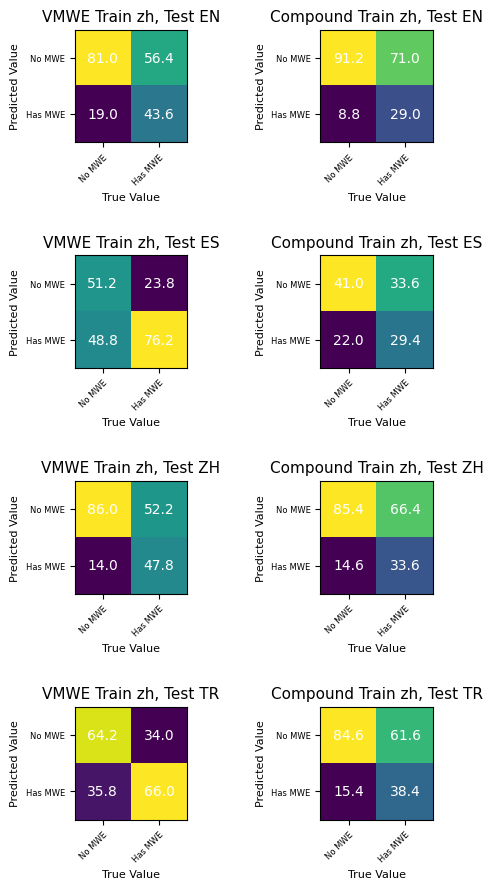

In [ ]:
a = get_base_metrics(0,5,'zh','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'zh','EN','compound_fewshot')
c = get_base_metrics(0,5,'zh','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'zh','ES','compound_fewshot')
e = get_base_metrics(0,5,'zh','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'zh','ZH','compound_fewshot')
g = get_base_metrics(0,5,'zh','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'zh','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

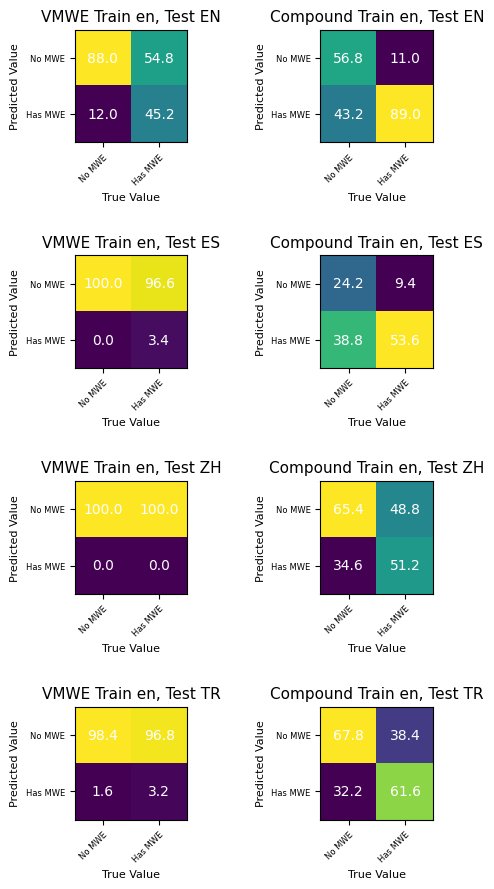

In [ ]:
a = get_base_metrics(0,5,'en','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'en','EN','compound_fewshot')
c = get_base_metrics(0,5,'en','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'en','ES','compound_fewshot')
e = get_base_metrics(0,5,'en','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'en','ZH','compound_fewshot')
g = get_base_metrics(0,5,'en','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'en','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

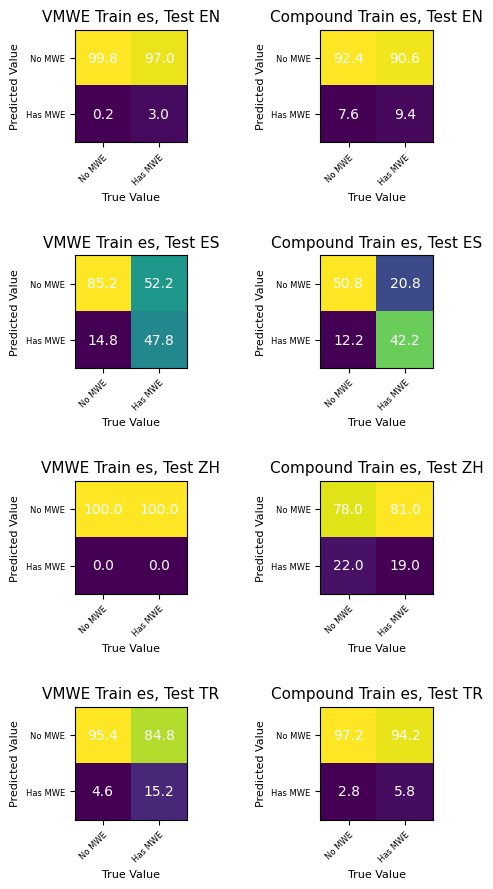

In [ ]:
a = get_base_metrics(0,5,'es','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'es','EN','compound_fewshot')
c = get_base_metrics(0,5,'es','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'es','ES','compound_fewshot')
e = get_base_metrics(0,5,'es','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'es','ZH','compound_fewshot')
g = get_base_metrics(0,5,'es','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'es','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

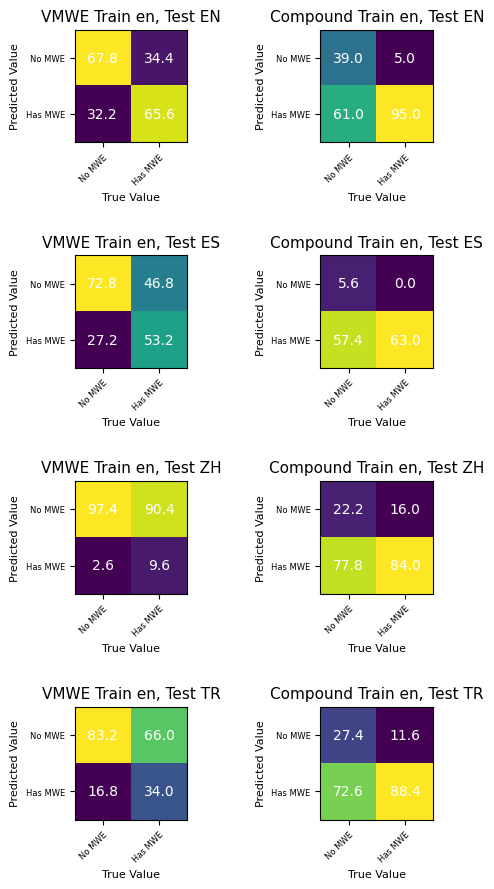

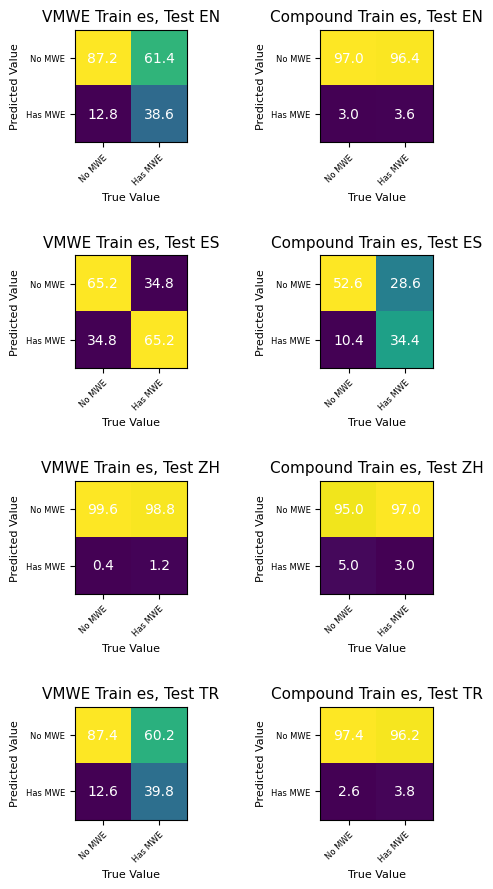

In [ ]:
a = get_base_metrics(0,5,'en','EN','vmwe_0shot')
b = get_base_metrics(0,5,'en','EN','compound_0shot')
c = get_base_metrics(0,5,'en','ES','vmwe_0shot')
d = get_base_metrics(0,5,'en','ES','compound_0shot')
e = get_base_metrics(0,5,'en','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'en','ZH','compound_0shot')
g = get_base_metrics(0,5,'en','TR','vmwe_0shot')
h = get_base_metrics(0,5,'en','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,5,'es','EN','vmwe_0shot')
b = get_base_metrics(0,5,'es','EN','compound_0shot')
c = get_base_metrics(0,5,'es','ES','vmwe_0shot')
d = get_base_metrics(0,5,'es','ES','compound_0shot')
e = get_base_metrics(0,5,'es','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'es','ZH','compound_0shot')
g = get_base_metrics(0,5,'es','TR','vmwe_0shot')
h = get_base_metrics(0,5,'es','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

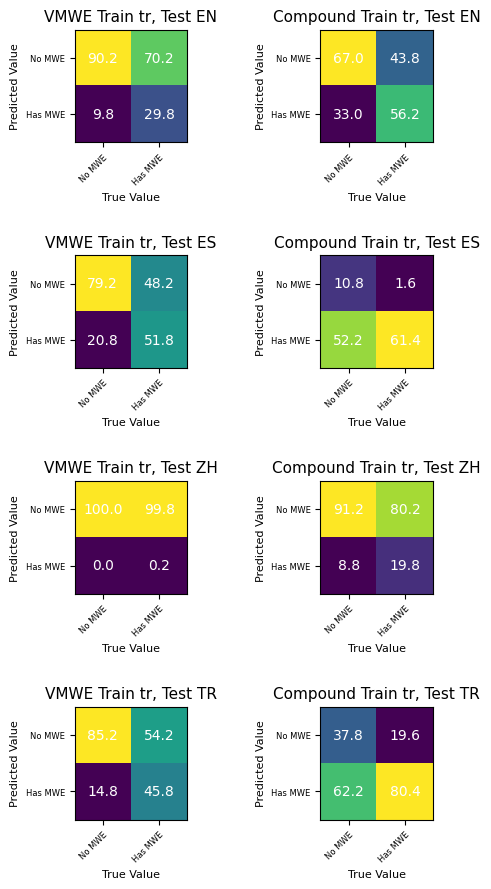

In [ ]:
a = get_base_metrics(0,5,'tr','EN','vmwe_0shot')
b = get_base_metrics(0,5,'tr','EN','compound_0shot')
c = get_base_metrics(0,5,'tr','ES','vmwe_0shot')
d = get_base_metrics(0,5,'tr','ES','compound_0shot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'tr','ZH','compound_0shot')
g = get_base_metrics(0,5,'tr','TR','vmwe_0shot')
h = get_base_metrics(0,5,'tr','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

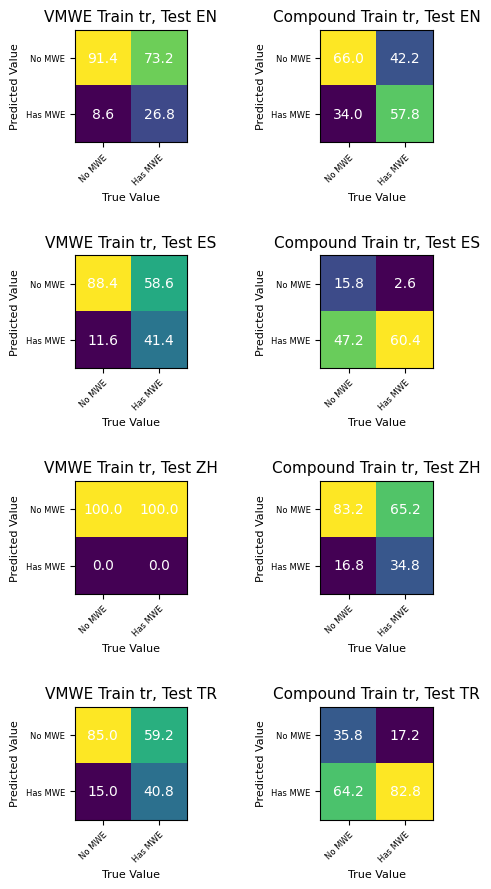

In [ ]:
a = get_base_metrics(0,5,'tr','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'tr','EN','compound_fewshot')
c = get_base_metrics(0,5,'tr','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'tr','ES','compound_fewshot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'tr','ZH','compound_fewshot')
g = get_base_metrics(0,5,'tr','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'tr','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

In [ ]:
path = '/content/drive/MyDrive/capstone/'

folder = 'results/qwen-32b/'

def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]

import matplotlib.pyplot as plt
import numpy as np


def make_confusion_matrix(result, language_pairs):
  #adapted from https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
  #6 items in results
  a = np.array(result[0])
  fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),(ax7,ax8)) = plt.subplots(4,2, figsize = (6,10))
  plt.subplots_adjust(wspace = 0.05, hspace = 1, left = 0.1, top = 0.9)
  im1 = ax1.imshow(result[0])
  ax1.set_xticks(range(2),labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax1.set_yticks(range(2),labels = ['No MWE','Has MWE'], fontsize = 6)
  ax1.set_xlabel('True Value', fontsize = 8)
  ax1.set_ylabel('Predicted Value', fontsize = 8)
  ax1.set_title('VMWE Train ' + language_pairs[0][0] + ', Test ' + language_pairs[0][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax1.text(j, i, result[0][i][j], ha = 'center', va='center',color='w')
  im2 = ax2.imshow(result[1])
  ax2.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax2.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax2.set_xlabel('True Value', fontsize = 8)
  ax2.set_ylabel('Predicted Value', fontsize = 8)
  ax2.set_title('Compound Train ' + language_pairs[1][0] + ', Test ' + language_pairs[1][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax2.text(j, i, result[1][i][j], ha = 'center', va='center',color='w')
  im3 = ax3.imshow(result[2])
  ax3.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax3.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax3.set_xlabel('True Value', fontsize = 8)
  ax3.set_ylabel('Predicted Value', fontsize = 8)
  ax3.set_title('VMWE Train ' + language_pairs[2][0] + ', Test ' + language_pairs[2][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax3.text(j, i, result[2][i][j], ha = 'center', va='center',color='w')
  im4 = ax4.imshow(result[3])
  ax4.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax4.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax4.set_xlabel('True Value', fontsize = 8)
  ax4.set_ylabel('Predicted Value', fontsize = 8)
  ax4.set_title('Compound Train ' + language_pairs[3][0] + ', Test ' + language_pairs[3][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax4.text(j, i, result[3][i][j], ha = 'center', va='center',color='w')
  im5 = ax5.imshow(result[4])
  ax5.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax5.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax5.set_xlabel('True Value', fontsize = 8)
  ax5.set_ylabel('Predicted Value', fontsize = 8)
  ax5.set_title('VMWE Train ' + language_pairs[4][0] + ', Test ' + language_pairs[4][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax5.text(j, i, result[4][i][j], ha = 'center', va='center',color='w')
  im6 = ax6.imshow(result[5])
  ax6.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax6.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax6.set_xlabel('True Value', fontsize = 8)
  ax6.set_ylabel('Predicted Value', fontsize = 8)
  ax6.set_title('Compound Train ' + language_pairs[5][0] + ', Test ' + language_pairs[5][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax6.text(j, i, result[5][i][j], ha = 'center', va='center',color='w')
  im7 = ax7.imshow(result[6])
  ax7.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax7.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax7.set_xlabel('True Value', fontsize = 8)
  ax7.set_ylabel('Predicted Value', fontsize = 8)
  ax7.set_title('VMWE Train ' + language_pairs[6][0] + ', Test ' + language_pairs[6][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax7.text(j, i, result[6][i][j], ha = 'center', va='center',color='w')
  im8 = ax8.imshow(result[7])
  ax8.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax8.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax8.set_xlabel('True Value', fontsize = 8)
  ax8.set_ylabel('Predicted Value', fontsize = 8)
  ax8.set_title('Compound Train ' + language_pairs[7][0] + ', Test ' + language_pairs[7][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax8.text(j, i, result[7][i][j], ha = 'center', va='center',color='w')
  plt.show()

"""
a = get_base_metrics(0,5,'tr','EN','vmwe_0shot')
b = get_base_metrics(0,5,'tr','EN','compound_0shot')
c = get_base_metrics(0,5,'tr','ES','vmwe_0shot')
d = get_base_metrics(0,5,'tr','ES','compound_0shot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'tr','ZH','compound_0shot')
g = get_base_metrics(0,5,'tr','TR','vmwe_0shot')
h = get_base_metrics(0,5,'tr','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))

#print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))



#print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'en','EN','compound_0shot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ES','compound_0shot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'es','EN','compound_0shot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ES','compound_0shot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','EN','compound_0shot'))
print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ES','compound_0shot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','EN','compound_0shot'))
print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ES','compound_0shot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

"""

"\na = get_base_metrics(0,5,'tr','EN','vmwe_0shot')\nb = get_base_metrics(0,5,'tr','EN','compound_0shot')\nc = get_base_metrics(0,5,'tr','ES','vmwe_0shot')\nd = get_base_metrics(0,5,'tr','ES','compound_0shot')\ne = get_base_metrics(0,5,'tr','ZH','vmwe_0shot')\nf = get_base_metrics(0,5,'tr','ZH','compound_0shot')\ng = get_base_metrics(0,5,'tr','TR','vmwe_0shot')\nh = get_base_metrics(0,5,'tr','TR','compound_0shot')\n\nmake_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])\n\nprint(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))\nprint(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))\n#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))\nprint()\n

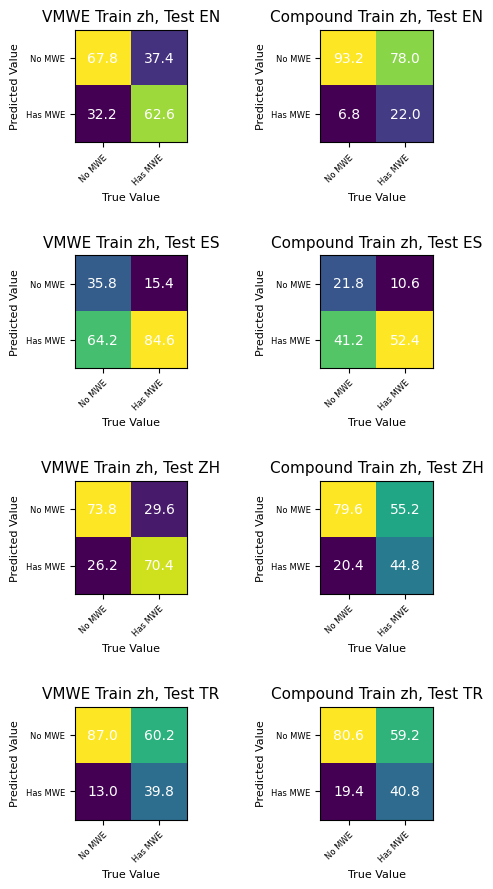

In [ ]:
a = get_base_metrics(0,5,'zh','EN','vmwe_0shot')
b = get_base_metrics(0,5,'zh','EN','compound_0shot')
c = get_base_metrics(0,5,'zh','ES','vmwe_0shot')
d = get_base_metrics(0,5,'zh','ES','compound_0shot')
e = get_base_metrics(0,5,'zh','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'zh','ZH','compound_0shot')
g = get_base_metrics(0,5,'zh','TR','vmwe_0shot')
h = get_base_metrics(0,5,'zh','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

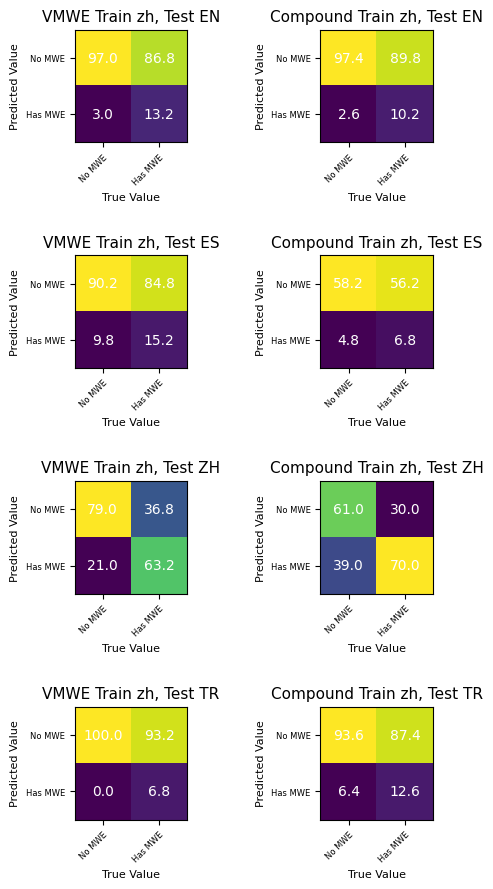

In [ ]:
a = get_base_metrics(0,5,'zh','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'zh','EN','compound_fewshot')
c = get_base_metrics(0,5,'zh','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'zh','ES','compound_fewshot')
e = get_base_metrics(0,5,'zh','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'zh','ZH','compound_fewshot')
g = get_base_metrics(0,5,'zh','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'zh','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

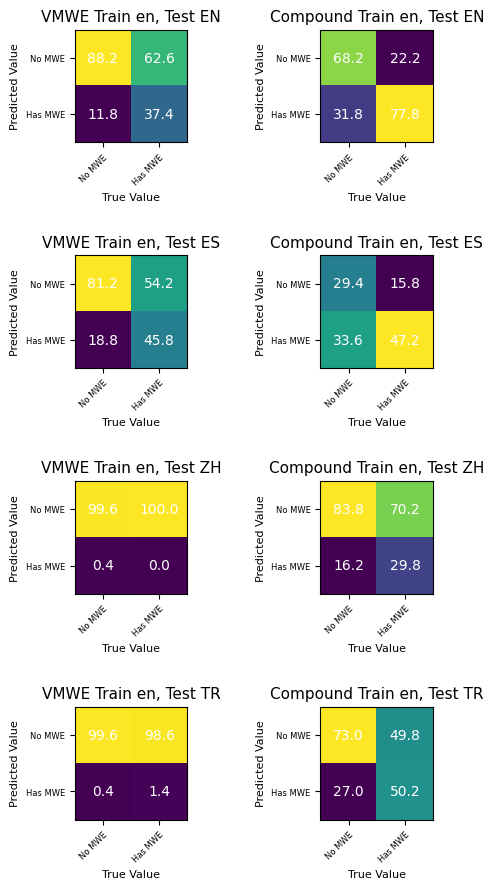

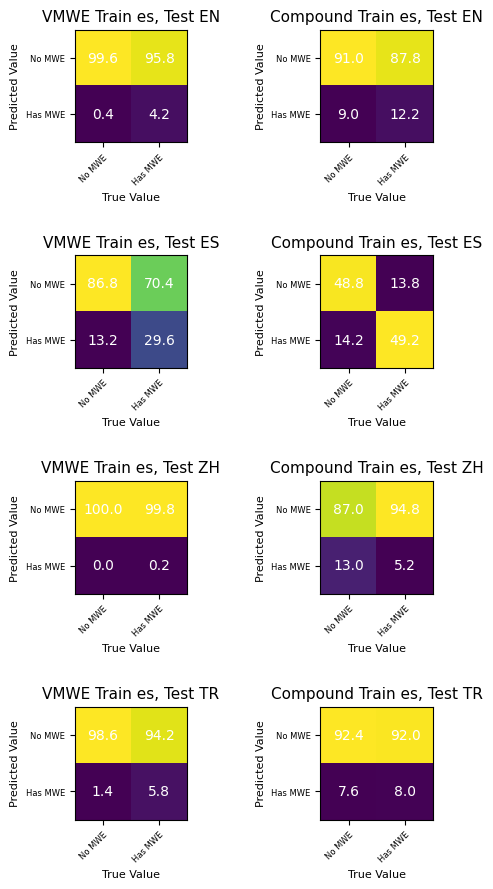

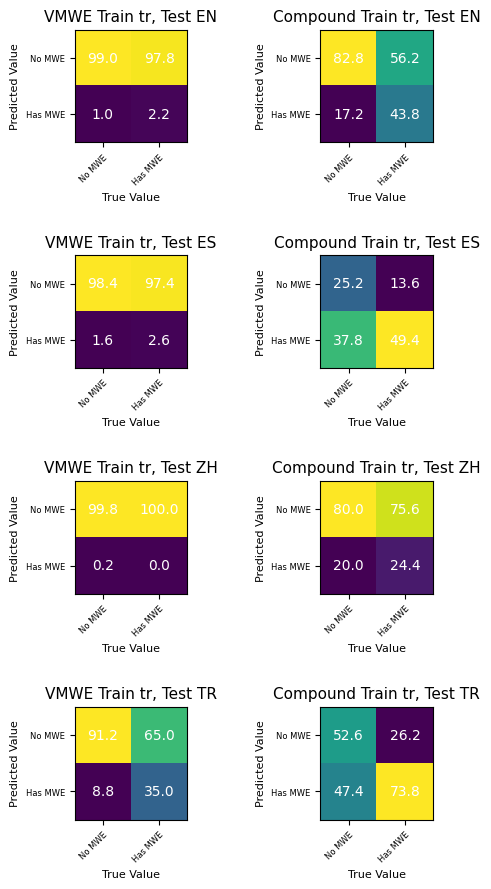

In [ ]:
a = get_base_metrics(0,5,'en','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'en','EN','compound_fewshot')
c = get_base_metrics(0,5,'en','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'en','ES','compound_fewshot')
e = get_base_metrics(0,5,'en','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'en','ZH','compound_fewshot')
g = get_base_metrics(0,5,'en','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'en','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,5,'es','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'es','EN','compound_fewshot')
c = get_base_metrics(0,5,'es','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'es','ES','compound_fewshot')
e = get_base_metrics(0,5,'es','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'es','ZH','compound_fewshot')
g = get_base_metrics(0,5,'es','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'es','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,5,'tr','EN','vmwe_fewshot')
b = get_base_metrics(0,5,'tr','EN','compound_fewshot')
c = get_base_metrics(0,5,'tr','ES','vmwe_fewshot')
d = get_base_metrics(0,5,'tr','ES','compound_fewshot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_fewshot')
f = get_base_metrics(0,5,'tr','ZH','compound_fewshot')
g = get_base_metrics(0,5,'tr','TR','vmwe_fewshot')
h = get_base_metrics(0,5,'tr','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

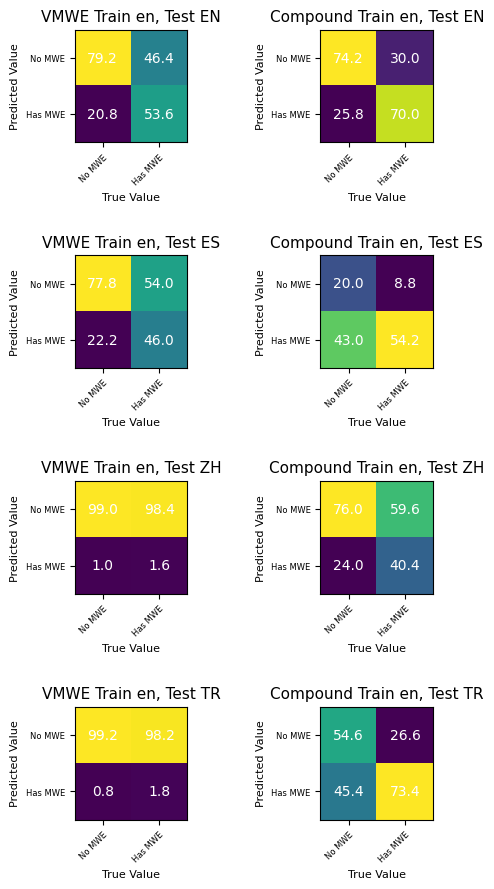

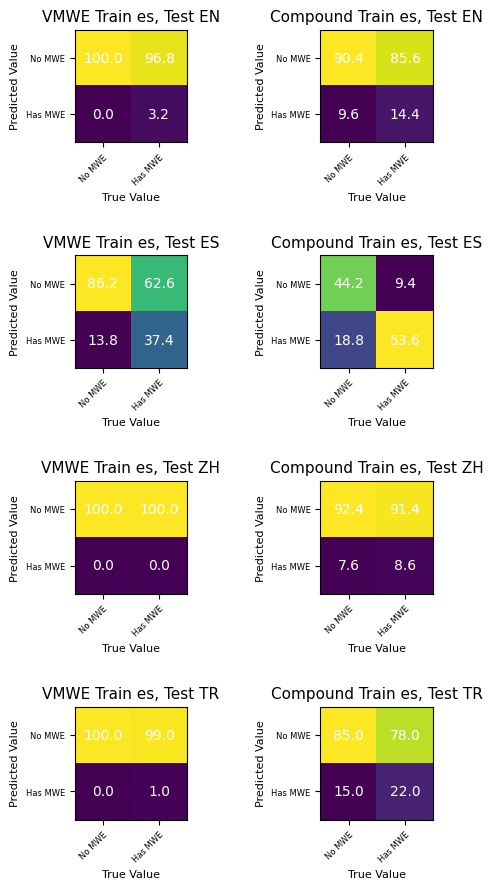

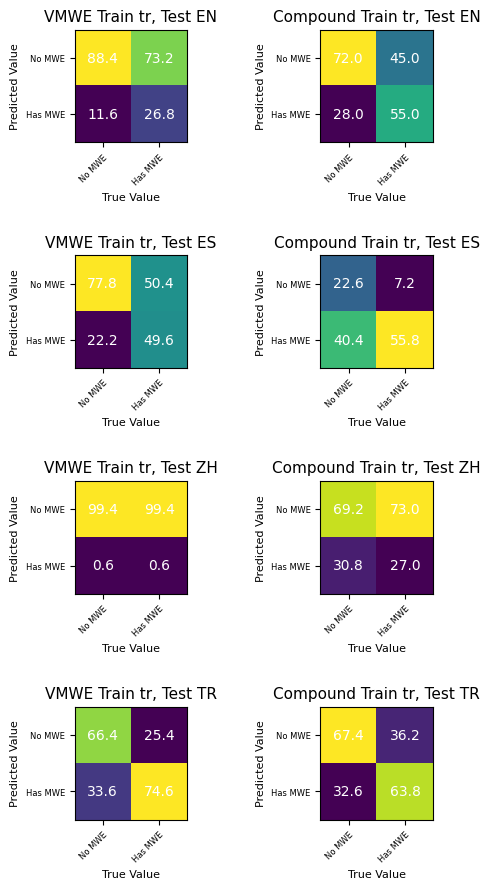

In [ ]:
a = get_base_metrics(0,5,'en','EN','vmwe_0shot')
b = get_base_metrics(0,5,'en','EN','compound_0shot')
c = get_base_metrics(0,5,'en','ES','vmwe_0shot')
d = get_base_metrics(0,5,'en','ES','compound_0shot')
e = get_base_metrics(0,5,'en','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'en','ZH','compound_0shot')
g = get_base_metrics(0,5,'en','TR','vmwe_0shot')
h = get_base_metrics(0,5,'en','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,5,'es','EN','vmwe_0shot')
b = get_base_metrics(0,5,'es','EN','compound_0shot')
c = get_base_metrics(0,5,'es','ES','vmwe_0shot')
d = get_base_metrics(0,5,'es','ES','compound_0shot')
e = get_base_metrics(0,5,'es','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'es','ZH','compound_0shot')
g = get_base_metrics(0,5,'es','TR','vmwe_0shot')
h = get_base_metrics(0,5,'es','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,5,'tr','EN','vmwe_0shot')
b = get_base_metrics(0,5,'tr','EN','compound_0shot')
c = get_base_metrics(0,5,'tr','ES','vmwe_0shot')
d = get_base_metrics(0,5,'tr','ES','compound_0shot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'tr','ZH','compound_0shot')
g = get_base_metrics(0,5,'tr','TR','vmwe_0shot')
h = get_base_metrics(0,5,'tr','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

In [ ]:
path = '/content/drive/MyDrive/capstone/'

folder = 'results/qwen-32b-base/'

def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]


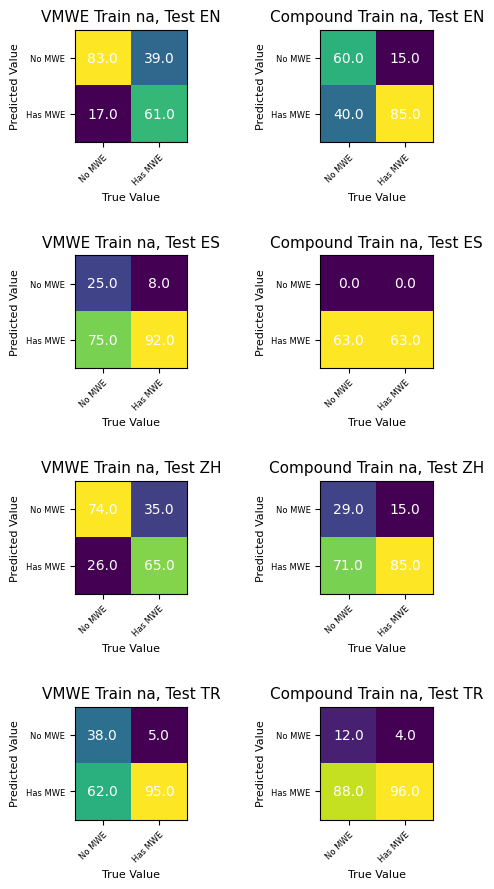

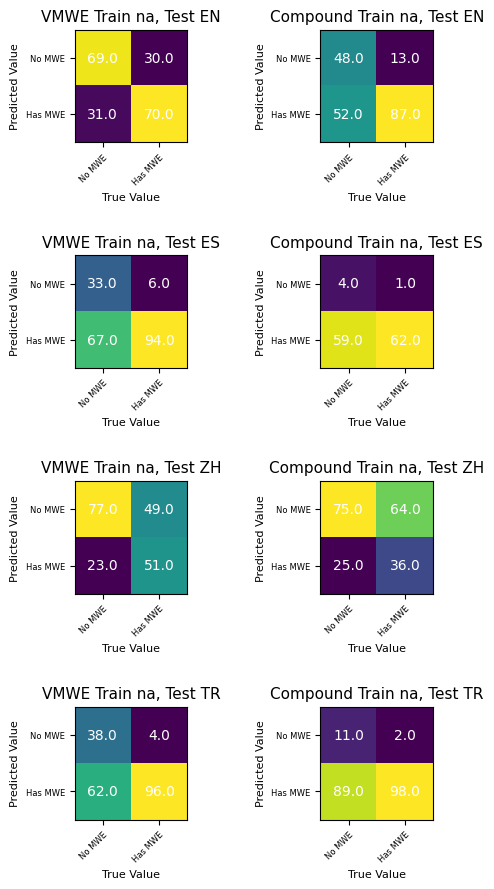

In [ ]:
a = get_base_metrics(0,1,'na','EN','vmwe_fewshot')
b = get_base_metrics(0,1,'na','EN','compound_fewshot')
c = get_base_metrics(0,1,'na','ES','vmwe_fewshot')
d = get_base_metrics(0,1,'na','ES','compound_fewshot')
e = get_base_metrics(0,1,'na','ZH','vmwe_fewshot')
f = get_base_metrics(0,1,'na','ZH','compound_fewshot')
g = get_base_metrics(0,1,'na','TR','vmwe_fewshot')
h = get_base_metrics(0,1,'na','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,1,'na','EN','vmwe_0shot')
b = get_base_metrics(0,1,'na','EN','compound_0shot')
c = get_base_metrics(0,1,'na','ES','vmwe_0shot')
d = get_base_metrics(0,1,'na','ES','compound_0shot')
e = get_base_metrics(0,1,'na','ZH','vmwe_0shot')
f = get_base_metrics(0,1,'na','ZH','compound_0shot')
g = get_base_metrics(0,1,'na','TR','vmwe_0shot')
h = get_base_metrics(0,1,'na','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

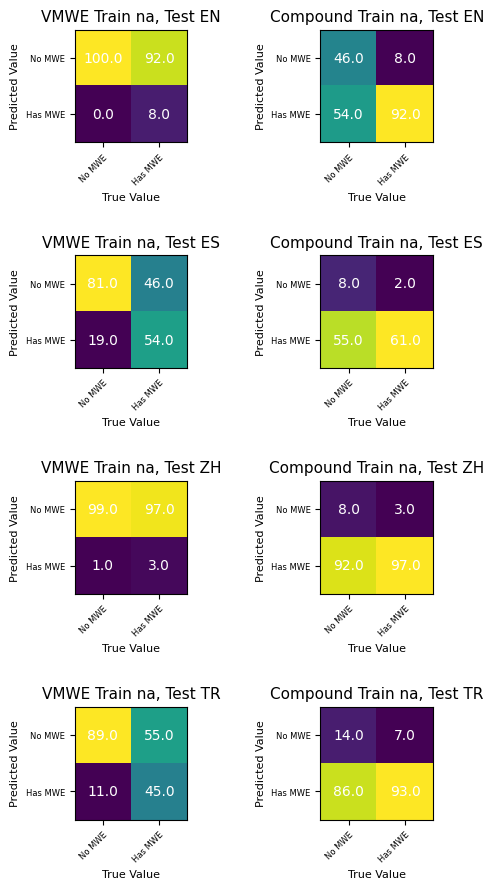

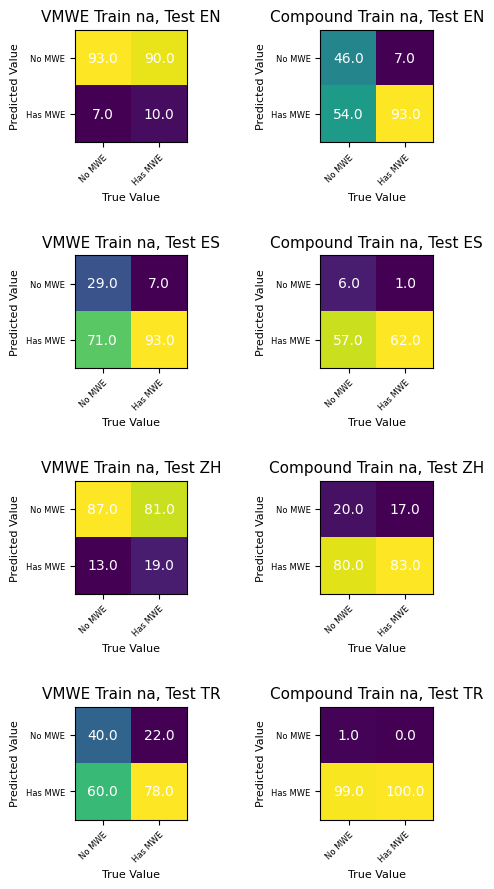

In [ ]:
path = '/content/drive/MyDrive/capstone/'

folder = 'results/llama-8b-base/'
from math import isnan

def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]

a = get_base_metrics(0,1,'na','EN','vmwe_fewshot')
b = get_base_metrics(0,1,'na','EN','compound_fewshot')
c = get_base_metrics(0,1,'na','ES','vmwe_fewshot')
d = get_base_metrics(0,1,'na','ES','compound_fewshot')
e = get_base_metrics(0,1,'na','ZH','vmwe_fewshot')
f = get_base_metrics(0,1,'na','ZH','compound_fewshot')
g = get_base_metrics(0,1,'na','TR','vmwe_fewshot')
h = get_base_metrics(0,1,'na','TR','compound_fewshot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

a = get_base_metrics(0,1,'na','EN','vmwe_0shot')
b = get_base_metrics(0,1,'na','EN','compound_0shot')
c = get_base_metrics(0,1,'na','ES','vmwe_0shot')
d = get_base_metrics(0,1,'na','ES','compound_0shot')
e = get_base_metrics(0,1,'na','ZH','vmwe_0shot')
f = get_base_metrics(0,1,'na','ZH','compound_0shot')
g = get_base_metrics(0,1,'na','TR','vmwe_0shot')
h = get_base_metrics(0,1,'na','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

In [4]:
#model_names = ['vmwe_0shot', 'vmwe_fewshot']#,
model_names = ['compound_0shot','compound_fewshot']
folders = ['llama-8b-base', 'qwen-32b-base']
path = '/content/drive/MyDrive/capstone/results/'
#train_langs = ['en','es','zh','tr']
train_langs = ['na']
test_langs = ['EN','ES','ZH','TR']
from math import isnan
from statistics import mean

def gen_total_scores(train_langs, test_langs, model_names, folders):
  for model in folders:
    results = {'model': [], 'setup': [], 'train': [], 'test': [], 'overall_score': [], 'precision': [], 'recall': [], 'f1': []}
    for lang_train in train_langs:

      for lang_test in test_langs:

        for model_name in model_names:
          b = pd.read_csv(path+model+'-scored/'+model_name+'_train_'+lang_train+'_test_'+lang_test+'_summary.csv')
          scores = []
          prec = []
          rec = []
          f1 = []
          for seed in range(0,1):
            b1 = b[b['seed']==str(seed)]
            score = b1.iloc[0]['average_score']
            if isnan(score) or (score is None):
              score = 0
            data = pd.read_csv(path + model + '/'+ model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(seed) + '.csv')
            metric = metrics(data, model_name)
            scores.append((1 * metric[4] + 0 * metric[5] + 0* metric[6]+score*metric[7])/metric[8])
            if (metric[6] + metric[7] != 0) and (metric[5]+metric[7] != 0):
              p = score*metric[7]/(metric[6]+metric[7])
              r = score*metric[7]/(metric[5]+metric[7])

              prec.append(p)
              rec.append(r)

              if (p!= 0) and (r!=0):
                f1.append(2*p*r/(p+r))
          overall_score = mean(scores)


          if len(prec)!=0:
            precision = mean(prec)
            recall = mean(rec)
            if len(f1)!=0:
              f_1 = mean(f1)
            else:
              f_1 = float('nan')
          else:
            precision = float('nan')
            recall = float('nan')
            f_1 = float('nan')


          results['model'].append(model)
          results['setup'].append(model_name)
          results['train'].append(lang_train)
          results['test'].append(lang_test)
          results['overall_score'].append(overall_score)
          results['precision'].append(precision)
          results['recall'].append(recall)
          results['f1'].append(f_1)
    results = pd.DataFrame(results)
    results.to_csv(path+model+'-scored/compound_overall.csv')
gen_total_scores(train_langs, test_langs, model_names, folders)